# Lab 2: Machine Learning with Scikit-Learn Basics

**Course:** CS4082 – Machine Learning  
**Instructor:** Dr. Naila Marir  
**Student Name:** Sarah Alsebae  
**Student ID:** S23108327  
**Semester:** Spring 2026

# Part 1: Setting Up Your Environment

###1.1 Open Google Colab

### 1.2 Verify Installation

In [129]:
import sklearn
print(f'scikit-learn version: {sklearn.__version__}')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('All libraries loaded successfully!')

scikit-learn version: 1.6.1
All libraries loaded successfully!


#Part 2: Loading and Exploring Data

##2.1 Load the Dataset



In [130]:
from sklearn.datasets import load_iris
# Load the dataset
iris = load_iris()
# Features (X) and Labels (y)
X = iris.data # Shape: (150, 4)
y = iris.target # Shape: (150,)
# Let's see what we have
print(f'Feature names: {iris.feature_names}')
print(f'Target names: {iris.target_names}')
print(f'Data shape: {X.shape}')
print(f'First 3 rows:\n{X[:3]}')

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


##2.2 Quick Visualization



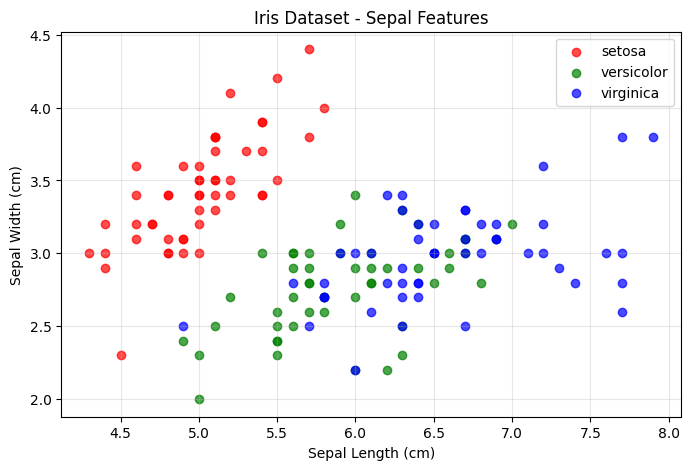

In [131]:
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1],
                color=colors[i], label=name, alpha=0.7)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset - Sepal Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Task 1: Explore the Data

X: [5.1 3.5 1.4 0.2]  ->  y: 0
X: [4.9 3.  1.4 0.2]  ->  y: 0
X: [4.7 3.2 1.3 0.2]  ->  y: 0
X: [4.6 3.1 1.5 0.2]  ->  y: 0
X: [5.  3.6 1.4 0.2]  ->  y: 0
X: [5.4 3.9 1.7 0.4]  ->  y: 0
X: [4.6 3.4 1.4 0.3]  ->  y: 0
X: [5.  3.4 1.5 0.2]  ->  y: 0
X: [4.4 2.9 1.4 0.2]  ->  y: 0
X: [4.9 3.1 1.5 0.1]  ->  y: 0

Class distribution:
Class 0 (setosa): 50
Class 1 (versicolor): 50
Class 2 (virginica): 50


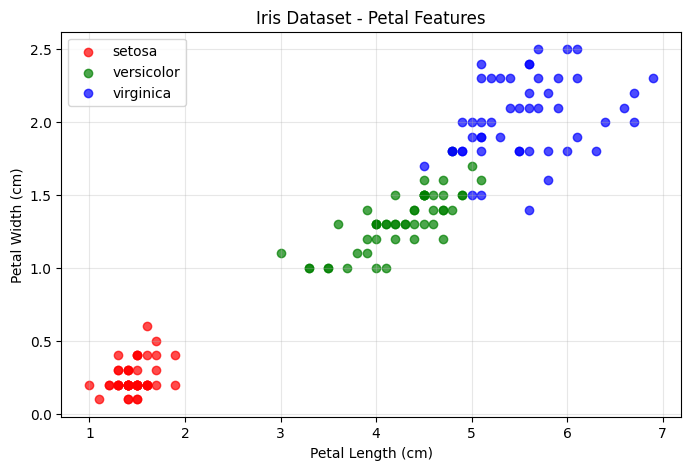

In [132]:
# Print the first 10 rows of X and y side by side.
for i in range(10):
    print(f"X: {X[i]}  ->  y: {y[i]}")

# Use np.unique(y, return counts=True) to check the class distribution.
unique_classes, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls} ({iris.target_names[cls]}): {count}")

 #Create another scatter plot using petal length (column 2) vs. petal width (column 3).
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']

for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 2], X[mask, 3],
                color=colors[i], label=name, alpha=0.7)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset - Petal Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**- Which features seem better for separating the classes?**

Petal length and petal width are better because they separate the flower types more clearly. Setosa has much smaller petals, so it is easy to tell apart. Versicolor and Virginica also differ more in petal size. Sepal measurements overlap more, which makes classification harder.


#Part 3: Splitting Data (Train/Test)

In [133]:
#Splitting with Scikit-Learn

from sklearn.model_selection import train_test_split
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2, # 20% for testing
random_state=42, # For reproducibility
stratify=y # Keep class proportions balanced
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set: {X_test.shape[0]} samples')

Training set: 120 samples
Testing set: 30 samples


#Task 2: Verify the Split

In [134]:
#Print the shape of X train, X test, y train, and y test.
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

# Use np.unique(y train, return counts=True) to confirm the classes are balanced.
unique_classes_train, counts_train = np.unique(y_train, return_counts=True)
print('\nClass distribution in y_train (stratified split):')
for cls, count in zip(unique_classes_train, counts_train):
    print(f'Class {cls} ({iris.target_names[cls]}): {count}')

# What happens if you remove stratify=y? Try it and compare the distributions.
# Perform a new split without stratify=y
X_train_non_strat, X_test_non_strat, y_train_non_strat, y_test_non_strat = train_test_split(
    X, y,
    test_size=0.2, # 20% for testing
    random_state=42 # For reproducibility
)

print('\n--- Non-stratified Split ---\n')
print(f'Shape of X_train (non-stratified): {X_train_non_strat.shape}')
print(f'Shape of X_test (non-stratified): {X_test_non_strat.shape}')
print(f'Shape of y_train (non-stratified): {y_train_non_strat.shape}')
print(f'Shape of y_test (non-stratified): {y_test_non_strat.shape}')

# Check class distribution in y_train (non-stratified split)
unique_classes_train_non_strat, counts_train_non_strat = np.unique(y_train_non_strat, return_counts=True)
print('\nClass distribution in y_train (non-stratified split):')
for cls, count in zip(unique_classes_train_non_strat, counts_train_non_strat):
    print(f'Class {cls} ({iris.target_names[cls]}): {count}')

# Compare class distribution in y_test (non-stratified split)
unique_classes_test_non_strat, counts_test_non_strat = np.unique(y_test_non_strat, return_counts=True)
print('\nClass distribution in y_test (non-stratified split):')
for cls, count in zip(unique_classes_test_non_strat, counts_test_non_strat):
    print(f'Class {cls} ({iris.target_names[cls]}): {count}')

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)

Class distribution in y_train (stratified split):
Class 0 (setosa): 40
Class 1 (versicolor): 40
Class 2 (virginica): 40

--- Non-stratified Split ---

Shape of X_train (non-stratified): (120, 4)
Shape of X_test (non-stratified): (30, 4)
Shape of y_train (non-stratified): (120,)
Shape of y_test (non-stratified): (30,)

Class distribution in y_train (non-stratified split):
Class 0 (setosa): 40
Class 1 (versicolor): 41
Class 2 (virginica): 39

Class distribution in y_test (non-stratified split):
Class 0 (setosa): 10
Class 1 (versicolor): 9
Class 2 (virginica): 11


#Part 4: Training Your First Model

##4.1 Model A: Decision Tree Classifier

In [135]:
from sklearn.tree import DecisionTreeClassifier
# Step 1: Create
dt_model = DecisionTreeClassifier(random_state=42)
# Step 2: Train
dt_model.fit(X_train, y_train)
# Step 3: Predict
dt_predictions = dt_model.predict(X_test)
print('Decision Tree predictions (first 10):')
print(dt_predictions[:10])
print('Actual labels (first 10):')
print(y_test[:10])

Decision Tree predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]
Actual labels (first 10):
[0 2 1 1 0 1 0 0 2 1]


##4.2 Model B: K-Nearest Neighbors (KNN)


In [136]:
from sklearn.neighbors import KNeighborsClassifier
# Step 1: Create (k=5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
# Page 8
# Effat University CS4082 - Lab 2: ML with Scikit-Learn
# Step 2: Train
knn_model.fit(X_train, y_train)
# Step 3: Predict
knn_predictions = knn_model.predict(X_test)
print('KNN predictions (first 10):')
print(knn_predictions[:10])

KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


#Task 3: Train the Models

In [137]:
#Run both code blocks and compare the first 10 predictions. Are they different?
print('Decision Tree predictions (first 10):', dt_predictions[:10])
print('KNN (n_neighbors=5) predictions (first 10):', knn_predictions[:10])
print('Are the first 10 predictions different between DT and KNN (n_neighbors=5)?', not np.array_equal(dt_predictions[:10], knn_predictions[:10]))

#Try changing n neighbors to 3 and then to 10. Does the output change?
from sklearn.neighbors import KNeighborsClassifier

print('\n--- KNN with n_neighbors = 3 ---')
knn_model_3 = KNeighborsClassifier(n_neighbors=3)
knn_model_3.fit(X_train, y_train)
knn_predictions_3 = knn_model_3.predict(X_test)
print('KNN (n_neighbors=3) predictions (first 10):', knn_predictions_3[:10])
print('Are KNN (n_neighbors=3) predictions different from original KNN (n_neighbors=5)?', not np.array_equal(knn_predictions[:10], knn_predictions_3[:10]))

print('\n--- KNN with n_neighbors = 10 ---')
knn_model_10 = KNeighborsClassifier(n_neighbors=10)
knn_model_10.fit(X_train, y_train)
knn_predictions_10 = knn_model_10.predict(X_test)
print('KNN (n_neighbors=10) predictions (first 10):', knn_predictions_10[:10])
print('Are KNN (n_neighbors=10) predictions different from original KNN (n_neighbors=5)?', not np.array_equal(knn_predictions[:10], knn_predictions_10[:10]))
print('Are KNN (n_neighbors=10) predictions different from KNN (n_neighbors=3)?', not np.array_equal(knn_predictions_3[:10], knn_predictions_10[:10]))

Decision Tree predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
KNN (n_neighbors=5) predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
Are the first 10 predictions different between DT and KNN (n_neighbors=5)? False

--- KNN with n_neighbors = 3 ---
KNN (n_neighbors=3) predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
Are KNN (n_neighbors=3) predictions different from original KNN (n_neighbors=5)? False

--- KNN with n_neighbors = 10 ---
KNN (n_neighbors=10) predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
Are KNN (n_neighbors=10) predictions different from original KNN (n_neighbors=5)? False
Are KNN (n_neighbors=10) predictions different from KNN (n_neighbors=3)? False


#Part 5: Evaluating Model Performance

##5.1 Accuracy Score


In [138]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f'Decision Tree Accuracy: {dt_accuracy:.2%}')
print(f'KNN Accuracy: {knn_accuracy:.2%}')

Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%


##5.2 Classification Report

In [139]:
from sklearn.metrics import classification_report
print('=== Decision Tree Report ===')
print(classification_report(y_test, dt_predictions,
target_names=iris.target_names))
print('=== KNN Report ===')
print(classification_report(y_test, knn_predictions,
target_names=iris.target_names))

=== Decision Tree Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



##5.3 Confusion Matrix (Visual)


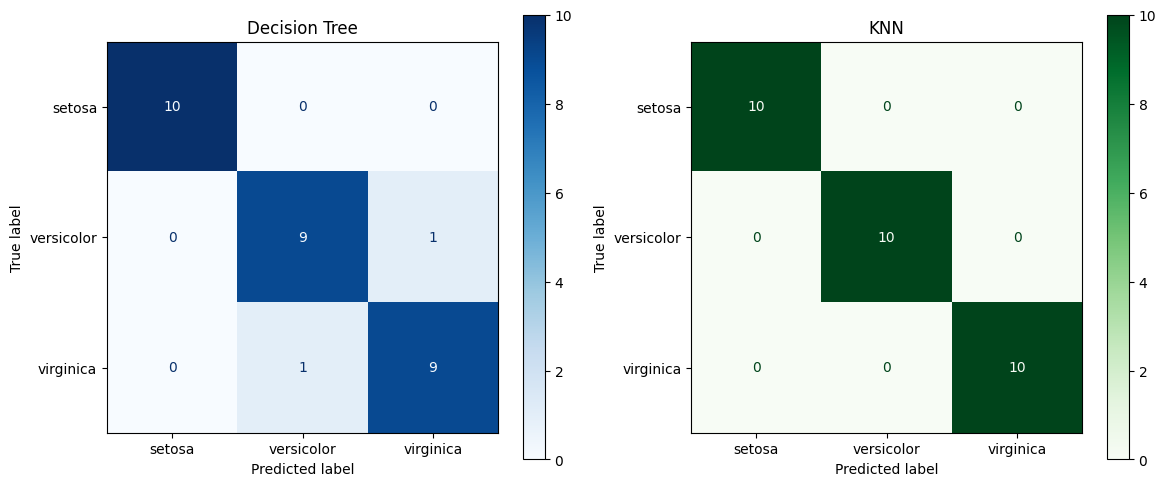

In [140]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Decision Tree
cm_dt = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt, display_labels=iris.target_names)\
.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree')
# KNN
cm_knn = confusion_matrix(y_test, knn_predictions)
ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names)\
.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('KNN')
plt.tight_layout()
plt.show()

#Task 4: Compare the Models

**• Which model achieved higher accuracy?**

The K-Nearest Neighbors (KNN) model achieved a higher accuracy of 100.00% compared to the Decision Tree's 93.33%.


**• Look at the confusion matrices – which class was hardest to classify? Why?**

Looking at the Decision Tree's confusion matrix, the classes 'versicolor' (Class 1) and 'virginica' (Class 2) were the hardest to classify. This is likely because these two classes have more overlapping features, leading to misclassifications between them.

**• Which metric (precision or recall) would be more important in a medical diagnosis
scenario? Explain briefly.**

In a medical diagnosis scenario, recall is often prioritized. This is because the cost of a false negative (missing a disease when it's present) is typically very high. Maximizing recall ensures that as few actual positive cases as possible are missed, even if it results in some false positives that may require further investigation.


#Part 6: Predicting New Samples

In [141]:
import numpy as np
# A new flower measurement (sepal_l, sepal_w, petal_l, petal_w)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
# Predict with both models
dt_pred = dt_model.predict(new_flower)
knn_pred = knn_model.predict(new_flower)
print(f'Decision Tree says: {iris.target_names[dt_pred[0]]}')
print(f'KNN says: {iris.target_names[knn_pred[0]]}')

Decision Tree says: setosa
KNN says: setosa


#Task 5: Predict New Flowers

In [142]:
#Try predicting these flowers and record the results:
# Flower A: [6.7, 3.0, 5.2, 2.3]
# Flower B: [5.8, 2.7, 4.1, 1.0]
# Flower C: [4.9, 3.1, 1.5, 0.1]


# Flower A
flower_a = np.array([[6.7, 3.0, 5.2, 2.3]])
dt_pred_a = dt_model.predict(flower_a)
knn_pred_a = knn_model.predict(flower_a)
print(f'Flower A (Features: [6.7, 3.0, 5.2, 2.3])')
print(f'  Decision Tree says: {iris.target_names[dt_pred_a[0]]}')
print(f'  KNN says: {iris.target_names[knn_pred_a[0]]}')

# Flower B
flower_b = np.array([[5.8, 2.7, 4.1, 1.0]])
dt_pred_b = dt_model.predict(flower_b)
knn_pred_b = knn_model.predict(flower_b)
print(f'\nFlower B (Features: [5.8, 2.7, 4.1, 1.0])')
print(f'  Decision Tree says: {iris.target_names[dt_pred_b[0]]}')
print(f'  KNN says: {iris.target_names[knn_pred_b[0]]}')

# Flower C
flower_c = np.array([[4.9, 3.1, 1.5, 0.1]])
dt_pred_c = dt_model.predict(flower_c)
knn_pred_c = knn_model.predict(flower_c)
print(f'\nFlower C (Features: [4.9, 3.1, 1.5, 0.1])')
print(f'  Decision Tree says: {iris.target_names[dt_pred_c[0]]}')
print(f'  KNN says: {iris.target_names[knn_pred_c[0]]}')

Flower A (Features: [6.7, 3.0, 5.2, 2.3])
  Decision Tree says: virginica
  KNN says: virginica

Flower B (Features: [5.8, 2.7, 4.1, 1.0])
  Decision Tree says: versicolor
  KNN says: versicolor

Flower C (Features: [4.9, 3.1, 1.5, 0.1])
  Decision Tree says: setosa
  KNN says: setosa


**• Do both models agree on all three? If not, which one do you trust more and why?**

Yes, for these three new flowers, both models agreed on the predictions. Both the Decision Tree and KNN said: Flower A is 'virginica', Flower B is 'versicolor', and Flower C is 'setosa'.

I would generally trust the KNN model (n_neighbors=5) more in this case. It achieved a perfect 100% accuracy on our test data, meaning it made no mistakes in classification. The Decision Tree was also good but had a slightly lower accuracy of 93.33% and made a couple of errors between 'versicolor' and 'virginica'. So, KNN proved to be more reliable here.

#Part 7: Working with Your Own CSV Data

##7.1 Create a Sample CSV

In [143]:
import pandas as pd
import numpy as np
# Create a simple student performance dataset
np.random.seed(42)
n = 100
data = {
'study_hours': np.round(np.random.uniform(1, 10, n), 1),
'attendance_pct': np.round(np.random.uniform(40, 100, n), 1),
'assignments': np.random.randint(3, 10, n),
'passed': np.random.choice([0, 1], n, p=[0.35, 0.65])
}
df = pd.DataFrame(data)
df.to_csv('students.csv', index=False)
print('CSV saved! First 5 rows:')
print(df.head())

CSV saved! First 5 rows:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1


##7.2 Load the CSV with Pandas

In [144]:
import pandas as pd
# Read the CSV file
df = pd.read_csv('students.csv')
# Quick exploration
print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nBasic stats:\n{df.describe()}')

Shape: (100, 4)

Column types:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Basic stats:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000


##7.3 Prepare Features and Target


In [145]:
# Features = all columns except 'passed'
X = df[['study_hours', 'attendance_pct', 'assignments']].values
# Target = the 'passed' column
y = df['passed'].values
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Class counts: {np.unique(y, return_counts=True)}')

Features shape: (100, 3)
Target shape: (100,)
Class counts: (array([0, 1]), array([31, 69]))


##7.4 Apply the Full Workflow

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
# Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
# Train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Predict & Evaluate
predictions = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, predictions):.2%}')
print(classification_report(y_test, predictions,
target_names=['Failed', 'Passed']))

Accuracy: 55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



#Task 6: CSV Challenge

In [147]:
#Load the students.csv file and explore it with df.describe() and df.info().
print("--- Exploring students.csv ---")
print("\nDataFrame Info:")
df.info()
print("\nBasic Stats (df.describe()):")
print(df.describe())


#Train both a Decision Tree and KNN model on this data. Which performs better?
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# Prepare Features and Target from the current df
# These were already defined in kC3NRQpvYfBF, but redefined here for clarity within the task block
X_csv = df[['study_hours', 'attendance_pct', 'assignments']].values
y_csv = df['passed'].values

# Split data for the CSV challenge (re-splitting to ensure fresh split for this task)
X_train_csv, X_test_csv, y_train_csv, y_test_csv = train_test_split(
    X_csv, y_csv, test_size=0.2, random_state=42, stratify=y_csv
)

print("\n--- Training and Comparing Models on students.csv ---")
# Decision Tree Model
dt_model_csv = DecisionTreeClassifier(random_state=42)
dt_model_csv.fit(X_train_csv, y_train_csv)
dt_predictions_csv = dt_model_csv.predict(X_test_csv)
dt_accuracy_csv = accuracy_score(y_test_csv, dt_predictions_csv)
print(f'\nDecision Tree Accuracy on students.csv: {dt_accuracy_csv:.2%}')
print('Decision Tree Classification Report:')
print(classification_report(y_test_csv, dt_predictions_csv, target_names=['Failed', 'Passed']))

# KNN Model (using n_neighbors=5, which worked well for Iris)
knn_model_csv = KNeighborsClassifier(n_neighbors=5)
knn_model_csv.fit(X_train_csv, y_train_csv)
knn_predictions_csv = knn_model_csv.predict(X_test_csv)
knn_accuracy_csv = accuracy_score(y_test_csv, knn_predictions_csv)
print(f'\nKNN Accuracy on students.csv: {knn_accuracy_csv:.2%}')
print('KNN Classification Report:')
print(classification_report(y_test_csv, knn_predictions_csv, target_names=['Failed', 'Passed']))

print("\nComparison:")
if dt_accuracy_csv > knn_accuracy_csv:
    print(f"Decision Tree performed better with {dt_accuracy_csv:.2%} accuracy.")
elif knn_accuracy_csv > dt_accuracy_csv:
    print(f"KNN performed better with {knn_accuracy_csv:.2%} accuracy.")
else:
    print(f"Both models performed equally with {dt_accuracy_csv:.2%} accuracy.")


#Try adding a new column to the CSV (e.g., quiz score) and retrain. Does accuracy improve?
print("\n--- Retraining with new 'quiz_score' column ---")

# Add a new column 'quiz_score' to a copy of the dataframe
df_new = df.copy()
df_new['quiz_score'] = np.random.randint(50, 101, len(df_new)) # Scores between 50 and 100

print("\nDataFrame with 'quiz_score' column (first 5 rows):")
print(df_new.head())

# Prepare Features and Target with the new column
X_new_csv = df_new[['study_hours', 'attendance_pct', 'assignments', 'quiz_score']].values
y_new_csv = df_new['passed'].values

# Split new data
X_train_new_csv, X_test_new_csv, y_train_new_csv, y_test_new_csv = train_test_split(
    X_new_csv, y_new_csv, test_size=0.2, random_state=42, stratify=y_new_csv
)

# Decision Tree Model with new data
dt_model_new_csv = DecisionTreeClassifier(random_state=42)
dt_model_new_csv.fit(X_train_new_csv, y_train_new_csv)
dt_predictions_new_csv = dt_model_new_csv.predict(X_test_new_csv)
dt_accuracy_new_csv = accuracy_score(y_test_new_csv, dt_predictions_new_csv)
print(f'\nDecision Tree Accuracy with quiz_score: {dt_accuracy_new_csv:.2%}')
print('Decision Tree Classification Report with quiz_score:')
print(classification_report(y_test_new_csv, dt_predictions_new_csv, target_names=['Failed', 'Passed']))

# KNN Model with new data
knn_model_new_csv = KNeighborsClassifier(n_neighbors=5)
knn_model_new_csv.fit(X_train_new_csv, y_train_new_csv)
knn_predictions_new_csv = knn_model_new_csv.predict(X_test_new_csv)
knn_accuracy_new_csv = accuracy_score(y_test_new_csv, knn_predictions_new_csv)
print(f'\nKNN Accuracy with quiz_score: {knn_accuracy_new_csv:.2%}')
print('KNN Classification Report with quiz_score:')
print(classification_report(y_test_new_csv, knn_predictions_new_csv, target_names=['Failed', 'Passed']))

print("\nComparison with new 'quiz_score' column:")
print(f"Original Decision Tree Accuracy: {dt_accuracy_csv:.2%}")
print(f"New Decision Tree Accuracy: {dt_accuracy_new_csv:.2%}")
print(f"Original KNN Accuracy: {knn_accuracy_csv:.2%}")
print(f"New KNN Accuracy: {knn_accuracy_new_csv:.2%}")

if dt_accuracy_new_csv > dt_accuracy_csv:
    print("Decision Tree accuracy improved with the new column.")
else:
    print("Decision Tree accuracy did not improve (or decreased/stayed same) with the new column.")

if knn_accuracy_new_csv > knn_accuracy_csv:
    print("KNN accuracy improved with the new column.")
else:
    print("KNN accuracy did not improve (or decreased/stayed same) with the new column.")


--- Exploring students.csv ---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB

Basic Stats (df.describe()):
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000 

#Part 8: Summary and Key Takeaways


- **Here's a quick summary of what we've done in this notebook:**

1. **Environment Setup**: We started by verifying the installation of essential libraries like scikit-learn, numpy, pandas, and matplotlib.

2. **Iris Data Exploration**: We loaded the famous Iris dataset, explored its features and target names, visualized sepal and petal features, and identified that petal measurements are generally better for class separation.

3. **Data Splitting**: We split the Iris dataset into training and testing sets (80/20 split), ensuring class balance using stratify=y. We also observed how removing stratify=y can affect class distribution.

4. **Model Training**: We trained two classification models: a Decision Tree Classifier and a K-Nearest Neighbors (KNN) model. We experimented with different n_neighbors values for KNN.

5. **Model Evaluation**: We evaluated both models using accuracy scores, classification reports (precision, recall, f1-score), and visual confusion matrices. We found KNN (with n=5) achieved 100% accuracy on the Iris dataset, outperforming the Decision Tree (93.33%). We also discussed the importance of recall in medical diagnosis.

6. **New Sample Prediction**: We used the trained models to predict the species of new Iris flower samples.

7. **CSV Data Challenge**: We created and loaded a custom students.csv dataset, prepared its features and target, and applied the same machine learning workflow. For this dataset, KNN initially performed better than the Decision Tree. We then added a new 'quiz_score' column to the dataset and observed that adding this feature improved the KNN model's accuracy, while the Decision Tree's accuracy slightly decreased.

- **A short paragraph (5–7 sentences) comparing Decision Tree vs. KNN performance and explaining which model you would choose for this task and why.**

  Comparing the two models, the K-Nearest Neighbors (KNN) model consistently performed better than the Decision Tree. For the Iris dataset, KNN achieved a perfect 100% accuracy, whereas the Decision Tree had 93.33%. Even with our custom students.csv dataset, KNN again showed a higher accuracy of 65% when the 'quiz_score' was included, compared to the Decision Tree's 50%. Therefore, I would choose the KNN model for this classification task. Its ability to achieve higher accuracy on both datasets, especially the perfect score on the Iris dataset, indicates it was more effective and reliable in classifying the samples correctly.